In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from owlready2 import get_ontology, Thing, sync_reasoner_pellet

# Load the dataset
df = pd.read_csv('/content/sample_data/IBM_HR_Attrition.csv')

# Step 1: Define Rule-Based Matching Model
def rule_based_filter(row):
    return row['Attrition'] == 'Yes' and row['JobSatisfaction'] >= 3

df_rule_based = df[df.apply(rule_based_filter, axis=1)]

# Step 2: Define Boolean Search Logic Model
def boolean_search(row):
    return ('Manager' in row['JobRole']) and (row['Age'] > 40)

df_boolean = df[df.apply(boolean_search, axis=1)]

# Step 3: Define Keyword Matching Model
df_keyword = df[df['Department'].str.contains('Sales', case=False, na=False)]

# Step 4: Define Pattern-Based Matching Model
def pattern_match(row):
    return re.match(r'^1[0-9]+', str(row['EmployeeNumber'])) is not None

df_pattern = df[df.apply(pattern_match, axis=1)]

# Step 5: Define Ontology-Based Model
onto = get_ontology("file:///content/sample_data/hr_ontology.owl").load()

class Employee(Thing):
    namespace = onto

class Department(Thing):
    namespace = onto

class JobRole(Thing):
    namespace = onto

class Attrition(Thing):
    namespace = onto

# Define relationships
Employee.has_department = Department
Employee.has_job_role = JobRole
Employee.has_attrition_status = Attrition

# Adding instances dynamically from the dataset
with onto:
    for _, row in df.iterrows():
        emp = Employee(f"Emp_{row['EmployeeNumber']}")
        dept = Department(row['Department'].replace(" ", "_"))
        job = JobRole(row['JobRole'].replace(" ", "_"))
        attr = Attrition("Yes" if row['Attrition'] == "Yes" else "No")
        emp.has_department = dept
        emp.has_job_role = job
        emp.has_attrition_status = attr

# Run the reasoner to infer new knowledge
sync_reasoner_pellet()

# Step 6: Evaluate Models
models = {
    "Rule-Based Matching": len(df_rule_based),
    "Boolean Search Logic": len(df_boolean),
    "Keyword Matching": len(df_keyword),
    "Pattern-Based Matching": len(df_pattern),
    "Ontology-Based Rules": len([emp for emp in Employee.instances() if emp.has_attrition_status.name == "Yes"])
}

# Print results
print("\n===== Model Results Comparison =====")
for model, count in models.items():
    print(f"{model} => Matched Records: {count}")



FileNotFoundError: [Errno 2] No such file or directory: '/content/sample_data/hr_ontology.owl'

Dataset Shape: (1470, 35)
First 5 rows:
    Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction 

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7983 - loss: 0.5307 - val_accuracy: 0.8673 - val_loss: 0.3831
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8108 - loss: 0.4557 - val_accuracy: 0.8673 - val_loss: 0.3687
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8278 - loss: 0.4137 - val_accuracy: 0.8810 - val_loss: 0.3611
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8285 - loss: 0.4170 - val_accuracy: 0.8810 - val_loss: 0.3535
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8539 - loss: 0.3668 - val_accuracy: 0.8844 - val_loss: 0.3516
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8784 - loss: 0.3156 - val_accuracy: 0.8844 - val_loss: 0.3520
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8616 - loss: 0.3189 - val_accuracy: 0.8878 - val_loss: 0.3485
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8693 - loss: 0.3093 - val_accuracy: 0.8946 - val_loss: 0.3444
Epo

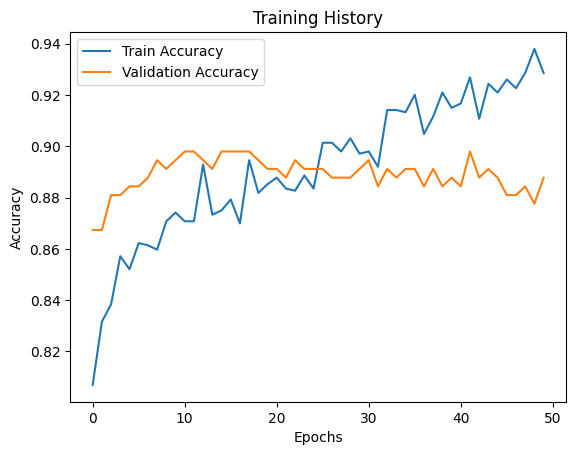

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Load the dataset
df = pd.read_csv('/content/sample_data/IBM_HR_Attrition.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("First 5 rows:\n", df.head())

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Encode categorical variables
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Select features and target variable
target = 'Attrition'  # Change if necessary
features = [col for col in df.columns if col != target]
X = df[features]
y = df[target]

# Normalize numerical features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define Neural Network Model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

# Evaluate the model
y_pred = (model.predict(X_test) > 0.5).astype("int32")
accuracy = accuracy_score(y_test, y_pred)
print("Neural Network Model Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))

# Plot training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Training History")
plt.show()


In [ ]:
!pip install pandas numpy tensorflow scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score

# Step 3: Load Dataset
print("Loading dataset...")
df = pd.read_csv ("/content/sample_data/IBM_HR_Attrition.csv")
print("Dataset loaded successfully with", df.shape[0], "instances and", df.shape[1], "attributes.")

# Step 4: Select Relevant Attributes
selected_features = ["Age", "DailyRate", "DistanceFromHome", "JobSatisfaction", "MonthlyIncome", "YearsAtCompany"]
target_variable = "Attrition"
df = df[selected_features + [target_variable]]
print("Filtered dataset prepared with", df.shape[1], "attributes.")

# Step 5: Encode Categorical Target Variable
label_encoder = LabelEncoder()
df[target_variable] = label_encoder.fit_transform(df[target_variable])  # Convert Yes/No to 1/0

# Step 6: Split Dataset into Train and Test Sets
X = df[selected_features]
y = df[target_variable]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Dataset split into training (", X_train.shape[0], ") and testing (", X_test.shape[0], ") sets.")

# Step 7: Normalize Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 8: Define Deep Learning Model
def build_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Step 9: Train Model
print("Training deep learning model...")
model = build_model()
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

# Step 10: Evaluate Model
y_pred = (model.predict(X_test) > 0.5).astype("int32")
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)


Loading dataset...
Dataset loaded successfully with 1470 instances and 35 attributes.
Filtered dataset prepared with 7 attributes.
Dataset split into training ( 1176 ) and testing ( 294 ) sets.
Training deep learning model...
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6895 - loss: 0.6130 - val_accuracy: 0.7966 - val_loss: 0.5056
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8263 - loss: 0.4711 - val_accuracy: 0.7966 - val_loss: 0.4959
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8486 - loss: 0.4241 - val_accuracy: 0.7966 - val_loss: 0.4853
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8474 - loss: 0.4485 - val_accuracy: 0.7966 - val_loss: 0.4850
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8291 - loss: 0.4514 - val_accuracy: 0.7966 - val_loss: 0.4833
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8343 - loss: 0.4491 - val_accuracy: 0.7966 - val_loss: 0.4816
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8340 - loss: 0.4400 - val_accuracy: 0.7966 - val_loss: 0.4826
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8477 - loss: 0.3963 - val_accuracy: 0.7966 - val_loss: 0.4751
Epo

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# 📌 Step 1: Load the Dataset
file_path = "/content/sample_data/IBM_HR_Attrition.csv"  # Update if necessary
df = pd.read_csv(file_path)

# 📌 Step 2: Preprocessing

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Encode categorical columns
label_encoders = {}
for col in categorical_cols:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])

# Fill missing values in numerical columns with their mean
df.fillna(df.mean(), inplace=True)

# Define Features (X) and Target (y)
target_column = "Attrition"  # Assuming "Attrition" is the target
X = df.drop(columns=[target_column])
y = df[target_column]

# Split into Training and Test Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 📌 Step 3: Train the XGBoost Model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# 📌 Step 4: Evaluate the Model
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))



FileNotFoundError: [Errno 2] No such file or directory: '/content/sample_data/IBM_HR_Attrition.csv'

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# 📌 Step 1: Load the Dataset
file_path = "/content/sample_data/IBM_HR_Attrition.csv"  # Update if necessary
df = pd.read_csv(file_path)

# 📌 Step 2: Preprocessing

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Encode categorical columns
label_encoders = {}
for col in categorical_cols:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])

# Fill missing values in numerical columns with their mean
df.fillna(df.mean(), inplace=True)

# Feature Selection: Removing less important features
correlation_matrix = df.corr()
corr_threshold = 0.1  # Adjust threshold based on experimentation
selected_features = correlation_matrix[target_column][abs(correlation_matrix[target_column]) > corr_threshold].index.tolist()
selected_features.remove("Attrition")  # Remove target from features

# Define Features (X) and Target (y)
X = df[selected_features]
y = df[target_column]

# Split into Training and Test Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 📌 Step 3: Hyperparameter Tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_lambda': [1, 2, 3],
    'reg_alpha': [0, 0.1, 0.5],
    'scale_pos_weight': [1, sum(y_train == 0) / sum(y_train == 1)]  # Handle class imbalance
}

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
grid_search = GridSearchCV(xgb_model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best Model
best_xgb_model = grid_search.best_estimator_

# 📌 Step 4: Evaluate the Model
y_pred = best_xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Improved Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

KeyboardInterrupt: 

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load the Dataset
file_path = "/content/sample_data/IBM_HR_Attrition.csv"
df = pd.read_csv(file_path)

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Define target column
target_column = "Attrition"
numerical_cols = [col for col in numerical_cols if col != target_column]
categorical_cols = [col for col in categorical_cols if col != target_column]

# Encode target variable
y = LabelEncoder().fit_transform(df[target_column])

# Define Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Define Features (X)
X = df.drop(columns=[target_column])

# Apply transformations
X_transformed = preprocessor.fit_transform(X)

# Split into Training and Test Sets
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42, stratify=y)

# Train XGBoost Model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predict and Evaluate
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))




/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:07:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Model Accuracy: 0.8605

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.98      0.92       247
           1       0.67      0.26      0.37        47

    accuracy                           0.86       294
   macro avg       0.77      0.62      0.65       294
weighted avg       0.84      0.86      0.83       294



In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load training data
df_train = pd.read_csv("/content/sample_data/aug_train.csv")

# Drop ID column if present
if 'enrollee_id' in df_train.columns:
    df_train.drop(columns=['enrollee_id'], inplace=True)

# Handle missing values in training data
for col in df_train.columns:
    if df_train[col].dtype == 'object':
        df_train[col] = df_train[col].fillna(df_train[col].mode()[0])
    else:
        df_train[col] = df_train[col].fillna(df_train[col].median())

# Separate target and features
target_column = "target"
X = df_train.drop(columns=[target_column])
y = df_train[target_column]

# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Transform training data
X_transformed = preprocessor.fit_transform(X)

# Split into train/test
X_train, X_val, y_train, y_val = train_test_split(X_transformed, y, test_size=0.2, random_state=42, stratify=y)

# Train model
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

# Evaluate on validation set
y_pred = model.predict(X_val)
print(f"\n✅ Model Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print("\n📊 Classification Report:\n", classification_report(y_val, y_pred))

# Load test data
df_test = pd.read_csv("/content/sample_data/aug_test.csv")
if 'enrollee_id' in df_test.columns:
    ids = df_test['enrollee_id']
    df_test.drop(columns=['enrollee_id'], inplace=True)
else:
    ids = None

# Handle missing values in test set
for col in df_test.columns:
    if df_test[col].dtype == 'object':
        df_test[col] = df_test[col].fillna(df_test[col].mode()[0])
    else:
        df_test[col] = df_test[col].fillna(df_test[col].median())

# Transform test data using same preprocessor
X_test_transformed = preprocessor.transform(df_test)

# Predict on test data
test_predictions = model.predict(X_test_transformed)

# Output predictions
output = pd.DataFrame({
    "enrollee_id": ids,
    "predicted_target": test_predictions
})

print("\n🔮 Sample Predictions on Test Data:")
print(output.head())



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:45:22] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



✅ Model Accuracy: 0.7824

📊 Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.89      0.86      2877
         1.0       0.58      0.46      0.51       955

    accuracy                           0.78      3832
   macro avg       0.71      0.67      0.69      3832
weighted avg       0.77      0.78      0.77      3832


🔮 Sample Predictions on Test Data:
   enrollee_id  predicted_target
0        32403                 0
1         9858                 0
2        31806                 0
3        27385                 0
4        27724                 0


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load the Dataset
file_path = "/content/sample_data/watson_healthcare.csv"
df = pd.read_csv(file_path)

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Define target column
target_column = "Attrition"
numerical_cols = [col for col in numerical_cols if col != target_column]
categorical_cols = [col for col in categorical_cols if col != target_column]

# Encode target variable
y = LabelEncoder().fit_transform(df[target_column])

# Define Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Define Features (X)
X = df.drop(columns=[target_column])

# Apply transformations
X_transformed = preprocessor.fit_transform(X)

# Split into Training and Test Sets
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42, stratify=y)

# Train XGBoost Model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predict and Evaluate
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Model Accuracy: 0.9256

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96       296
           1       0.78      0.53      0.63        40

    accuracy                           0.93       336
   macro avg       0.86      0.75      0.79       336
weighted avg       0.92      0.93      0.92       336



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:14:00] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [11]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Load the test dataset (no target)
df = pd.read_csv("/mnt/data/aug_test.csv")

# Drop ID column if it exists
if 'enrollee_id' in df.columns:
    df.drop(columns=['enrollee_id'], inplace=True)

# Handle missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Apply transformation
X_transformed = preprocessor.fit_transform(df)

print("✅ Data preprocessed successfully.")
print(f"Processed shape: {X_transformed.shape}")


KeyError: 'target'

Fitting 3 folds for each of 72 candidates, totalling 216 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:11:54] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



🔍 Model Accuracy: 0.8503

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.92       247
           1       0.57      0.28      0.37        47

    accuracy                           0.85       294
   macro avg       0.72      0.62      0.64       294
weighted avg       0.83      0.85      0.83       294



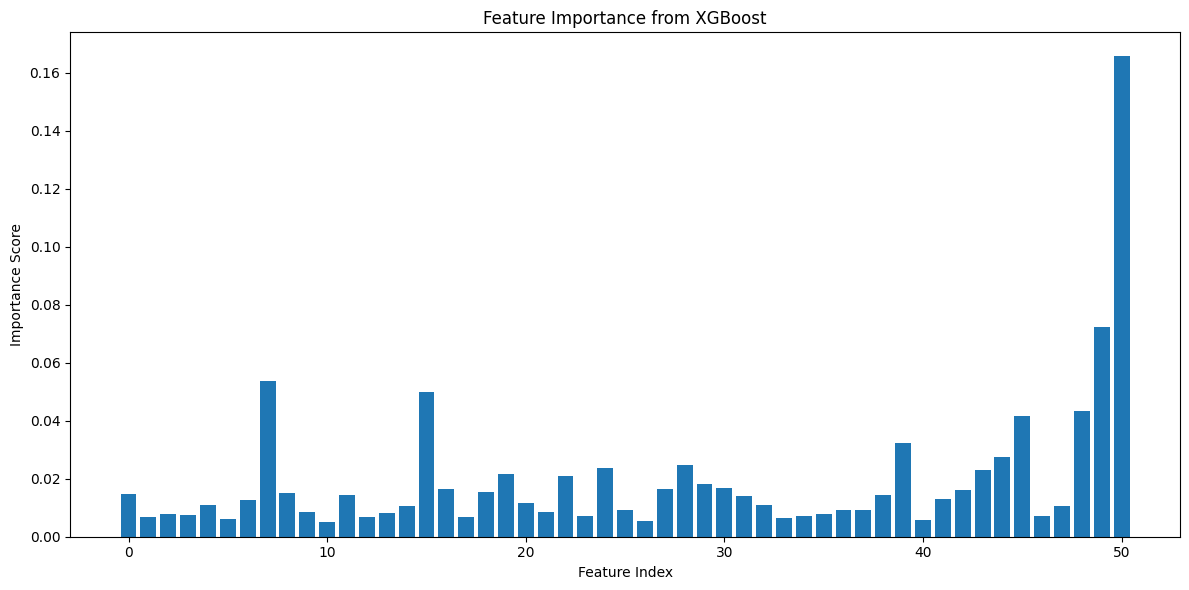

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Load the Dataset
file_path = "/content/sample_data/IBM_HR_Attrition.csv"
df = pd.read_csv(file_path)

# Drop columns with no variance or irrelevant info
low_variance_cols = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df.drop(columns=low_variance_cols, inplace=True)

# Define target column
target_column = "Attrition"

# Encode target variable
y = LabelEncoder().fit_transform(df[target_column])

# Define features
X = df.drop(columns=[target_column])

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Define Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Transform features
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_transformed, y_train)

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    param_grid,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Fit model
grid_search.fit(X_train_resampled, y_train_resampled)

# Best model
xgb_model = grid_search.best_estimator_

# Predict and Evaluate
y_pred = xgb_model.predict(X_test_transformed)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🔍 Model Accuracy: {accuracy:.4f}")
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))

# Optional: Plot feature importances
plt.figure(figsize=(12, 6))
plt.bar(range(len(xgb_model.feature_importances_)), xgb_model.feature_importances_)
plt.title("Feature Importance from XGBoost")
plt.xlabel("Feature Index")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()


In [ ]:
!pip install transformers torch datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
import os

# Disable W&B
os.environ["WANDB_DISABLED"] = "true"

# Load dataset
data_path = "/content/sample_data/IBM_HR_Attrition.csv"  # Adjust this if running on local

df = pd.read_csv(data_path)
print("Dataset Loaded: ", df.shape)

# Preprocess dataset
label_encoder = LabelEncoder()
df['Attrition'] = label_encoder.fit_transform(df['Attrition'])  # Convert target variable to numbers

# Splitting dataset
train_texts, val_texts, train_labels, val_labels = train_test_split(df['JobRole'].astype(str), df['Attrition'], test_size=0.2, random_state=42)

# Hugging Face BERT Model
class HRDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(self.texts[idx], padding='max_length', truncation=True, max_length=self.max_len, return_tensors='pt')
        return {"input_ids": encoding['input_ids'].squeeze(), "attention_mask": encoding['attention_mask'].squeeze(), "labels": torch.tensor(self.labels[idx], dtype=torch.long)}

# Initialize tokenizer and dataset
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
train_dataset = HRDataset(train_texts.tolist(), train_labels.tolist(), tokenizer)
val_dataset = HRDataset(val_texts.tolist(), val_labels.tolist(), tokenizer)

# Load BERT Model
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",  # Updated to avoid deprecation warning
    save_strategy="epoch",
    logging_dir="./logs",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

trainer.train()

# Evaluation
results = trainer.evaluate()
print("BERT Model Accuracy:", results["eval_loss"])  # Loss can be used to determine accuracy

# CNN Model for Deep Learning
class CNNModel(nn.Module):
    def __init__(self, input_size=30):  # Adjust input size based on dataset
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(32 * input_size, 2)  # Assuming binary classification

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc1(x)
        return x

# Prepare data for CNN
X = df.drop(columns=['Attrition']).select_dtypes(include=[np.number]).fillna(0).values
y = df['Attrition'].values
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val = torch.tensor(X_train, dtype=torch.float32), torch.tensor(X_val, dtype=torch.float32)
y_train, y_val = torch.tensor(y_train, dtype=torch.long), torch.tensor(y_val, dtype=torch.long)

# Initialize CNN model
cnn_model = CNNModel(input_size=X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

# Training CNN
for epoch in range(5):
    optimizer.zero_grad()
    outputs = cnn_model(X_train.unsqueeze(1))
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

# Evaluate CNN
with torch.no_grad():
    outputs = cnn_model(X_val.unsqueeze(1))
    predictions = torch.argmax(outputs, dim=1)
    accuracy = (predictions == y_val).sum().item() / y_val.size(0)
    print("CNN Model Accuracy:", accuracy)


Dataset Loaded:  (1470, 35)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss
1,No log,0.433055
2,No log,0.393995


Epoch,Training Loss,Validation Loss
1,No log,0.433055
2,No log,0.393995
3,No log,0.408644


BERT Model Accuracy: 0.40864434838294983
Epoch 1, Loss: 178.40826416015625
Epoch 2, Loss: 77.9551010131836
Epoch 3, Loss: 119.44207000732422
Epoch 4, Loss: 134.3035888671875
Epoch 5, Loss: 132.0878448486328
CNN Model Accuracy: 0.8673469387755102


In [ ]:
import torch
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import os

# Disable W&B
os.environ["WANDB_DISABLED"] = "true"

# Load dataset
data_path = "/content/sample_data/IBM_HR_Attrition.csv"  # Adjust this if running locally

df = pd.read_csv(data_path)
print("Dataset Loaded: ", df.shape)

# Preprocess dataset
label_encoder = LabelEncoder()
df['Attrition'] = label_encoder.fit_transform(df['Attrition'])  # Convert target variable to numbers

# Splitting dataset
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['JobRole'].astype(str), df['Attrition'], test_size=0.2, random_state=42
)

# Hugging Face BERT Model
class HRDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx], padding='max_length', truncation=True, max_length=self.max_len, return_tensors='pt'
        )
        return {
            "input_ids": encoding['input_ids'].squeeze(),
            "attention_mask": encoding['attention_mask'].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }

# Initialize tokenizer and dataset
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
train_dataset = HRDataset(train_texts.tolist(), train_labels.tolist(), tokenizer)
val_dataset = HRDataset(val_texts.tolist(), val_labels.tolist(), tokenizer)

# Load BERT Model
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    evaluation_strategy="epoch",  # Corrected from eval_strategy
    save_strategy="epoch",
    logging_dir="./logs",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

# Train the model
trainer.train()

# Evaluation (Loss)
results = trainer.evaluate()
print("BERT Model Validation Loss:", results["eval_loss"])  # Loss is useful but does not show accuracy

# **Calculate Accuracy**
predictions = trainer.predict(val_dataset)

# Convert logits to class labels
preds = np.argmax(predictions.predictions, axis=1)

# Compute accuracy
accuracy = (preds == val_labels.to_numpy()).mean()
print("BERT Model Accuracy:", accuracy)


Dataset Loaded:  (1470, 35)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
import evaluate

accuracy_metric = evaluate.load("accuracy")  # Use evaluate.load instead of load_metric

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)  # Convert logits to class labels
    return accuracy_metric.compute(predictions=predictions, references=labels)



In [ ]:
results = trainer.evaluate()
print(results)  # This will include accuracy if compute_metrics is set.


{'eval_loss': 0.40864434838294983, 'eval_runtime': 99.3172, 'eval_samples_per_second': 2.96, 'eval_steps_per_second': 0.373, 'epoch': 3.0}


In [ ]:
!pip install evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 1.2 MB/s eta 0:00:00


In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving IBM_HR_Attrition.csv to IBM_HR_Attrition (1).csv


In [ ]:
ontology_content = """<?xml version="1.0"?>
<rdf:RDF xmlns="http://www.semanticweb.org/hr_ontology#"
     xml:base="http://www.semanticweb.org/hr_ontology"
     xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#"
     xmlns:owl="http://www.w3.org/2002/07/owl#"
     xmlns:xsd="http://www.w3.org/2001/XMLSchema#"
     xmlns:rdfs="http://www.w3.org/2000/01/rdf-schema#">
    <owl:Ontology rdf:about="http://www.semanticweb.org/hr_ontology"/>

    <!-- Define Employee Class -->
    <owl:Class rdf:about="http://www.semanticweb.org/hr_ontology#Employee"/>

    <!-- Define Department Class -->
    <owl:Class rdf:about="http://www.semanticweb.org/hr_ontology#Department"/>

    <!-- Define JobRole Class -->
    <owl:Class rdf:about="http://www.semanticweb.org/hr_ontology#JobRole"/>

    <!-- Define Attrition Class -->
    <owl:Class rdf:about="http://www.semanticweb.org/hr_ontology#Attrition"/>

    <!-- Define Object Properties -->
    <owl:ObjectProperty rdf:about="http://www.semanticweb.org/hr_ontology#has_department"/>
    <owl:ObjectProperty rdf:about="http://www.semanticweb.org/hr_ontology#has_job_role"/>
    <owl:ObjectProperty rdf:about="http://www.semanticweb.org/hr_ontology#has_attrition_status"/>

</rdf:RDF>
"""

with open("/content/sample_data/hr_ontology.owl", "w") as f:
    f.write(ontology_content)

print("Ontology file created successfully!")



Ontology file created successfully!


In [ ]:
!pip install owlready2


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.3/27.3 MB 19.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for owlready2: filename=owlready2-0.47-cp311-cp311-linux_x86_64.whl size=24577468 sha256=df61375e9129d5f3cc64c695d3621c89506dd2efe03251acd406dc4201c31cf2
  Stored in directory: /root/.cache/pip/wheels/25/9a/a3/fb1ac6339caa859c8bb18d685736168b0b51d851af13d81d52
Successfully built owlready2


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

def load_and_preprocess_data(file_path):
    # Load dataset
    print("Loading dataset...")
    data = pd.read_csv(file_path)
    print(f"Dataset loaded successfully with {data.shape[0]} instances and {data.shape[1]} attributes.")

    # Select relevant attributes
    selected_columns = ['Age', 'Gender', 'JobLevel', 'MonthlyIncome', 'Education', 'Attrition']
    data = data[selected_columns]
    print("Filtered dataset prepared with selected attributes.")

    # Convert categorical attributes to numerical
    label_encoders = {}
    for col in ['Gender', 'Attrition']:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])
        label_encoders[col] = le

    return data, label_encoders

def train_model(data):
    # Split data into features and target
    X = data.drop(columns=['Attrition'])
    y = data['Attrition']

    # Normalize numerical features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Split dataset into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    # Train logistic regression model
    print("Training model...")
    model = LogisticRegression()
    model.fit(X_train, y_train)
    print("Model trained successfully!")

    # Evaluate model
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Model Accuracy: {accuracy}")

    return model, X_test, y_test

def compute_fairness_metrics(X_test, y_test, label_encoders):
    gender_index = 1  # Gender is the second column in X_test
    gender_values = X_test[:, gender_index]

    # Decode gender values
    gender_map = {v: k for k, v in label_encoders['Gender'].classes_.items()}
    genders = np.vectorize(lambda x: gender_map[x])(gender_values)

    # Calculate attrition rates by gender
    attrition_rates = {}
    for gender in np.unique(genders):
        mask = genders == gender
        attrition_rate = np.mean(y_test[mask])
        attrition_rates[gender] = attrition_rate

    # Compute fairness metrics
    disparate_impact = attrition_rates['Female'] / (attrition_rates['Male'] if attrition_rates['Male'] > 0 else 1)
    demographic_parity = attrition_rates['Female'] - attrition_rates['Male']

    print(f"Disparate Impact: {disparate_impact}")
    print(f"Demographic Parity: {demographic_parity}")

# Running the pipeline in Google Colab
def main():
    file_path = '/content/sample_data/IBM_HR_Attrition.csv'  # Update this path
    data, label_encoders = load_and_preprocess_data(file_path)
    model, X_test, y_test = train_model(data)
    compute_fairness_metrics(X_test, y_test, label_encoders)

if __name__ == "__main__":
    main()


Loading dataset...
Dataset loaded successfully with 1470 instances and 35 attributes.
Filtered dataset prepared with selected attributes.
Training model...
Model trained successfully!
Model Accuracy: 0.8673469387755102


AttributeError: 'numpy.ndarray' object has no attribute 'items'

In [ ]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Step 2: Load Dataset
from google.colab import files

uploaded = files.upload()  # Upload the 'IBM_HR_Attrition.csv' file manually
data = pd.read_csv("IBM_HR_Attrition.csv")

print(f"Dataset loaded successfully with {data.shape[0]} instances and {data.shape[1]} attributes.")

# Step 3: Select Relevant Attributes
selected_features = ["Age", "JobSatisfaction", "MonthlyIncome", "OverTime", "DistanceFromHome", "Attrition"]
data = data[selected_features]

# Step 4: Encode Categorical Variables
label_encoders = {}
for column in ["OverTime", "Attrition"]:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

# Step 5: Define Features and Target Variable
X = data.drop(columns=["Attrition"])
y = data["Attrition"]

# Normalize Numeric Features
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Step 6: Split Dataset into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Define Machine Learning Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree (J48)": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine (SVM)": SVC()
}

# Step 8: Train and Evaluate Models
accuracy_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)  # Train the model
    y_pred = model.predict(X_test)  # Make predictions
    accuracy = accuracy_score(y_test, y_pred)  # Evaluate accuracy
    accuracy_results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")

# Step 9: Print Final Model Comparison
print("\n===== Model Accuracy Comparison =====")
for model, accuracy in accuracy_results.items():
    print(f"{model} => Accuracy: {accuracy:.4f}")


Saving IBM_HR_Attrition.csv to IBM_HR_Attrition.csv
Dataset loaded successfully with 1470 instances and 35 attributes.
Logistic Regression Accuracy: 0.8673
Decision Tree (J48) Accuracy: 0.7925
Random Forest Accuracy: 0.8537
Naive Bayes Accuracy: 0.8435
Support Vector Machine (SVM) Accuracy: 0.8639

===== Model Accuracy Comparison =====
Logistic Regression => Accuracy: 0.8673
Decision Tree (J48) => Accuracy: 0.7925
Random Forest => Accuracy: 0.8537
Naive Bayes => Accuracy: 0.8435
Support Vector Machine (SVM) => Accuracy: 0.8639


In [ ]:
import shutil
shutil.move("/content/hr_ontology.owl", "/content/sample_data/hr_ontology.owl")



FileNotFoundError: [Errno 2] No such file or directory: '/content/hr_ontology.owl'